In [1]:
import torch
torch.version

<module 'torch.version' from 'c:\\Users\\PC\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages\\torch\\version.py'>

In [2]:
# make some data
import sklearn
from sklearn.datasets import make_circles

n_samples = 1000

# create circles
x,y = make_circles(n_samples=n_samples,
                  noise=0.03,random_state=42)

In [3]:
x[:5]

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       [-0.39373073,  0.69288277],
       [ 0.44220765, -0.89672343]])

In [4]:
y[:5]

array([1, 1, 1, 1, 0])

In [5]:
# make dataframe with pandas
import pandas as pd

cicrles = pd.DataFrame({"x1" : x[:,0] , "x2" : x[:,1], "y" : y})

In [6]:
cicrles

,x1,x2,y
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


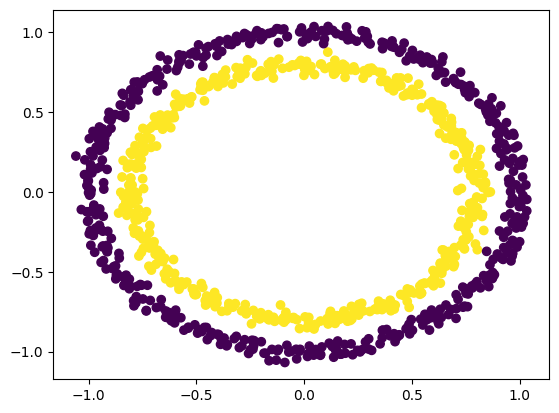

In [7]:
# visualize the things 
import matplotlib.pyplot as plt

plt.scatter(x=x[:,0] ,y=x[:,1] , c=y)

In [8]:
torch.manual_seed(42)

In [9]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train,y_test = train_test_split(x , y , test_size= 0.2 , random_state=42)

In [10]:
len(x_test) , len(x_train)

(200, 800)



## Steps to do

1- setup device agnostic code so it detects the gpu itself
2- construct a model
3- define a loss function and optimizer
4- make training loop


In [11]:
#  import pytorch and nn 
import torch 
from torch import nn
# device = "cuda" if torch.cuda.is_available() else "cpu"
device = "cpu"

device


'cpu'

In [12]:
x_train

array([[ 0.65794626, -0.46508097],
       [ 0.63194897, -0.7346633 ],
       [-1.00861631, -0.12403051],
       ...,
       [ 0.01574478, -1.02998534],
       [ 1.01102578,  0.16802846],
       [ 0.55778227, -0.57087612]], shape=(800, 2))

In [13]:
class CircleModelV0(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # creeate 2 nn.linear layers 
        self.layer_1 = nn.Linear(in_features=2 , out_features= 5)#TAKE 2 FEATURES ADN UPSACALE TO 5
        self.layer_2 = nn.Linear(in_features=5 , out_features=1) # output is the same shape as y 
    
    def forward(self, x):
        return self.layer_2(torch.sigmoid(self.layer_1(x)))  #x  -> layer_1 -> layer 2 -> output 
    
#  instantiate instance and send it top our target device
model = CircleModelV0().to(device=device)
model


CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [14]:
next(model.parameters()).device

device(type='cpu')

In [15]:
# lets replicate the model using the sequential 

model1 = nn.Sequential(
    nn.Linear(in_features= 2 , out_features= 5) , 
    nn.Linear(in_features= 5 , out_features=1 )
).to(device=device)

In [16]:
# setup loss function adn optimizer

# we will need either MAE or MSE for regression and for the classification we use iether the binary crossentropy or categorical cross entropy

loss_fn = nn.BCEWithLogitsLoss()  # it have the sigmoid activation function inside it

optimizer = torch.optim.SGD(params=model.parameters() , lr= 0.01)

In [17]:
# calculate the accuracy for the evaluation metrics for this problem 
def accuracy_fn(y_true , y_pred):
    correct = torch.eq(y_true , y_pred).sum().item()
    acc = (correct/len(y_pred)) *100
    return acc

In [18]:
# our model outputs will be the ra logits
# we need to make the raw logits > prediction probability > prediction label

#  view the first 5 outputs of the fwd pass on the test data
x_test = torch.tensor(x_test, dtype=torch.float32)
x_test = x_test.to(device)

y_logits = model(x_test)[:5]

y_logits


tensor([[-0.0607],
        [-0.0531],
        [-0.0760],
        [-0.0570],
        [-0.0714]], grad_fn=<SliceBackward0>)

In [19]:
y_pred_probs = torch.sigmoid(y_logits)

y_pred_probs

tensor([[0.4848],
        [0.4867],
        [0.4810],
        [0.4857],
        [0.4822]], grad_fn=<SigmoidBackward0>)

In [20]:
# find the predicted labels
torch.round(y_pred_probs)

y_pred_labels = torch.round(torch.sigmoid(model(x_test.to(device))))

y_pred_labels

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
      

In [21]:
# creating the training loop 
torch.manual_seed(42)

epochs = 1000

# Convert NumPy arrays to PyTorch tensors
x_train = torch.tensor(x_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)  # make y shape [N,1]
x_test  = torch.tensor(x_test, dtype=torch.float32).to(device)
y_test  = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)

# build training and evaluation loop
for epoch in range(epochs) :
    model.train()

    # fwd pass
    y_logits = model(x_train)
    y_pred = torch.round(torch.sigmoid(y_logits)) #> pred labels

    # calculate the loss/accuraccy
    loss = loss_fn(y_logits , y_train) # nn,bcewithlogits expects the loguits

    acc = accuracy_fn(y_true= y_train , y_pred=y_pred)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()


    # testing
    model.eval()
    with torch.inference_mode() : 
        test_logits = model(x_test)
        test_preds = torch.round( torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits , y_test)
        test_acc = accuracy_fn(y_test,test_preds)

    if(epoch%10 ==0) :
        print(f" epoch : {epoch} || loss : {loss:.5f}, acc {acc:.2f} | test Loss {test_loss:.5f}")

C:\Users\PC\AppData\Local\Temp\ipykernel_8804\1478866033.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_test  = torch.tensor(x_test, dtype=torch.float32).to(device)


 epoch : 0 || loss : 0.69356, acc 50.00 | test Loss 0.69399
 epoch : 10 || loss : 0.69348, acc 50.00 | test Loss 0.69393
 epoch : 20 || loss : 0.69342, acc 50.00 | test Loss 0.69388
 epoch : 30 || loss : 0.69336, acc 50.00 | test Loss 0.69383
 epoch : 40 || loss : 0.69331, acc 50.00 | test Loss 0.69379
 epoch : 50 || loss : 0.69327, acc 50.00 | test Loss 0.69376
 epoch : 60 || loss : 0.69323, acc 50.00 | test Loss 0.69373
 epoch : 70 || loss : 0.69320, acc 50.00 | test Loss 0.69371
 epoch : 80 || loss : 0.69317, acc 50.00 | test Loss 0.69368
 epoch : 90 || loss : 0.69315, acc 50.00 | test Loss 0.69367
 epoch : 100 || loss : 0.69313, acc 50.00 | test Loss 0.69365
 epoch : 110 || loss : 0.69311, acc 50.00 | test Loss 0.69364
 epoch : 120 || loss : 0.69309, acc 50.00 | test Loss 0.69363
 epoch : 130 || loss : 0.69308, acc 50.00 | test Loss 0.69362
 epoch : 140 || loss : 0.69306, acc 50.00 | test Loss 0.69361
 epoch : 150 || loss : 0.69305, acc 48.75 | test Loss 0.69361
 epoch : 160 || los

In [22]:
test_acc

45.5

In [23]:
acc

52.25

In [24]:
def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y.

    Source - https://madewithml.com/courses/foundations/neural-networks/ (with modifications)
    """
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())


In [25]:
# visualize the predictions as the model does seem to not be learning anything 

import requests 
from pathlib import Path

# dowbload helper functions if it is not already downloaded

if Path("helper_functions.py").is_file() :
    print("helper_functions.py already exoists skipping loadding....")
else :
    print("downloading ya momlesh.......")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")

    with open("helper_functions.py" ,"wb" ) as f:
        f.write(request.content)

# from helper_functions.py

helper_functions.py already exoists skipping loadding....


In [26]:
from helper_functions import plot_predictions , plot_decision_boundary

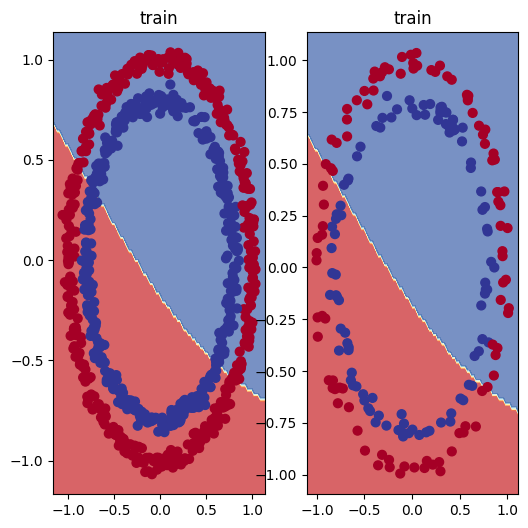

In [27]:
plt.figure(figsize=(6,6))

plt.subplot(1,2,1)

plt.title("train")
plot_decision_boundary(model , x_train , y_train)


plt.subplot(1,2,2)

plt.title("train")
plot_decision_boundary(model , x_test , y_test)